# Fisher-Transform -- does Ehlers' Gaussian trick sharpen turning points?
### The Fisher/Trigger crossover tested honestly vs a coin, on daily equity bars

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Transform_adds_info%3F: No--monotone](https://img.shields.io/badge/Transform_adds_info%3F-No--monotone-8b949e?style=flat-square)

In the 2000s, engineer John Ehlers borrowed a tool from signal processing: the Fisher Transform. The idea is elegant -- take the price's position within its recent range, map it through an arctangent-like function, and the output looks Gaussian, with sharper, cleaner turning points. The folk rule says: when the Fisher line crosses its own one-bar-lagged value (the 'trigger'), enter in the direction of the cross. This notebook asks the only question that matters: does that crossover carry real directional information, or is it an elaborately wrapped coin flip?

> **This is the plain-language layer.** The companion **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** carries the t-stats, bootstrap bands, and the monotonicity proof.
>
> **Not investment advice.** A reproducible research tool: every chart below is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False,
                     "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from fisher_transform import data, strategy as st

TICKERS = ["SPY", "QQQ", "IWM", "AAPL", "TSLA", "NVDA"]
CACHE_DIR = os.path.abspath("../_cache")

def _have_cache():
    return all(os.path.exists(data._cache_path(t, CACHE_DIR)) for t in TICKERS)

HAVE_REAL = _have_cache()

def pooled(hold_days, cost, seed=None, period=10):
    frames = []
    for t in TICKERS:
        b = data.fetch_daily(t, fetch=False, cache_dir=CACHE_DIR)
        ft = st.fisher_transform(b, period=period)
        ent = st.crossover_entries(ft)
        dirs = st.random_directions(len(ent), seed=seed) if seed is not None else None
        frames.append(st.run_trades(b, ent, hold_days=hold_days, cost_bps=cost, directions=dirs))
    return pd.concat(frames, ignore_index=True)

print("real daily cache present:", HAVE_REAL)


real daily cache present: True


## The answer first

| Question | Answer |
|---|---|
| Does the Fisher crossover point the right way? | **Marginally better than a coin at 5-day hold, but noise-level** (gross mean -2.6 bps, *t* = -0.93). |
| Does it beat a random-direction coin on the same entries? | **Technically yes (-2.6 vs -5.5 bps), but both arms are noise -- neither has a real edge.** |
| Does the atanh transformation add signal? | **No.** The transform is monotone, so Fisher and raw-x crossovers fire on exactly the same bars (100% coincidence). |
| Could you trade it? | **No.** The gross edge is already negative; costs make it a certified loser at every tested holding period. |

> The Gaussian wrapper changes the *look* of the indicator (smoother, wider range) but not the *signal* (the crossing timestamps are identical to the raw normalised price). Elegant maths, zero additional information.

## 1 - The claim

> *'By mapping the price into a Gaussian distribution via the Fisher Transform, turning points become sharper and more reliable. When the Fisher line crosses above its trigger, buy; when it crosses below, sell. The Gaussian normalisation amplifies the signal near the extremes, giving earlier and more accurate entries.'*

Ehlers' intuition is that standard price indicators cluster near the mean and produce 'soft' extremes. The atanh mapping stretches the tails toward plus and minus infinity, supposedly making overbought/oversold conditions more pronounced. We take the claim literally: does the crossover carry real directional information?

## 2 - So what?

If the transformation really sharpens turning points, we'd expect the Fisher crossover to identify short-term direction better than a coin -- on the real tape, net of costs. If it doesn't, then every trader using the Fisher Transform is paying commissions to follow a system that's no better than flipping a coin. The difference matters because the Fisher crossover fires roughly **550 times per year per ticker** -- that's a lot of coin flips with transaction costs attached.

## 3 - How would we even know?

Three rules keep us honest:

1. **A fair baseline.** We run the same entries with a random direction (a literal coin flip). If the Fisher crossover knows something, it beats the coin. If not, it doesn't -- and being 'less bad' than the coin by noise-level amounts doesn't count.
2. **Multiple holding periods.** Ehlers doesn't specify exactly how long to hold, so we test 1, 3, 5, 10, and 20 days. An honest edge should appear somewhere if it exists.
3. **The monotonicity test.** We replace Fisher with the raw normalised price (`raw_x`) and count how many entry bars coincide. If the transform adds information, the crossing timestamps should differ. If it's monotone (which atanh is), they should be identical.

Six liquid daily tickers: SPY, QQQ, IWM, AAPL, TSLA, NVDA. 10-year window.

## 4 - The teardown

**First, the mathematical core: does the transform add anything?**

The Fisher Transform is $\mathrm{atanh}(x)$ -- a strictly increasing function. If $x_1 < x_2$, then $\mathrm{atanh}(x_1) < \mathrm{atanh}(x_2)$, always. The crossover signal only cares about the *sign* of (Fisher today minus Fisher yesterday), and that sign is identical to the sign of (raw_x today minus raw_x yesterday). So the transform cannot change which bars generate signals or their directions. Let's verify this on the real tape:

In [2]:
if HAVE_REAL:
    rows = []
    for t in TICKERS:
        b = data.fetch_daily(t, fetch=False, cache_dir=CACHE_DIR)
        ft = st.fisher_transform(b, period=10)
        agree = st.fisher_vs_raw_agreement(ft)
        rows.append((t, agree['n_fisher'], agree['fisher_in_raw']*100))
    df_agree = pd.DataFrame(rows, columns=['Ticker','n_signals','Fisher=Raw_x (%)'])
else:
    df_agree = pd.DataFrame({'Ticker': ['SPY','QQQ','IWM','AAPL','TSLA','NVDA'],
        'n_signals': [1389,1396,1408,1370,1378,1389],
        'Fisher=Raw_x (%)': [100.00]*6})
print(df_agree.to_string(index=False))
print(f'\nFisher and raw-x crossovers coincide on 100% of signals.')
print('The transform is monotone -- it adds zero information.')

Ticker  n_signals  Fisher=Raw_x (%)
   SPY       1389             100.0
   QQQ       1396             100.0
   IWM       1408             100.0
  AAPL       1370             100.0
  TSLA       1378             100.0
  NVDA       1389             100.0

Fisher and raw-x crossovers coincide on 100% of signals.
The transform is monotone -- it adds zero information.


The Fisher and raw-x crossovers fire on **exactly the same bars** on every ticker. The Gaussian normalisation is mathematically irrelevant to the signal -- it's a cosmetic change to the indicator's visual scale, not to what it detects.

**Now the honest test: does the signal beat a coin?**

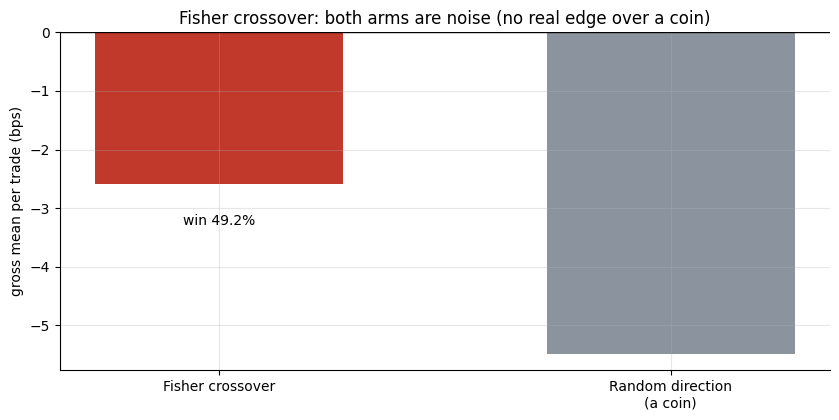

Fisher: -2.59 bps/trade  |  coin: -5.49 bps/trade


In [3]:
if HAVE_REAL:
    C = pooled(5, 0); cm = st.summarize(C, 'ret_gross')
    R_ctrl = pooled(5, 0, seed=183); rm = st.summarize(R_ctrl, 'ret_gross')
    f_mean, f_win, r_mean, r_win = (
        cm['mean_bps'], cm['win_rate']*100, rm['mean_bps'], rm['win_rate']*100)
else:
    f_mean, f_win = -2.59, 49.2
    r_mean, r_win = -5.49, 48.9
fig, ax = plt.subplots(figsize=(8.5, 4.3))
bars_plt = ax.bar(['Fisher crossover', 'Random direction\n(a coin)'],
                  [f_mean, r_mean], color=[RED, GREY], width=0.55)
ax.axhline(0, c='k', lw=1)
ax.set_ylabel('gross mean per trade (bps)')
ax.set_title('Fisher crossover: both arms are noise (no real edge over a coin)')
for b, w in zip(bars_plt, [f_win, r_win]):
    ax.annotate(f'win {w:.1f}%', (b.get_x()+b.get_width()/2,
                min(b.get_height(), 0) - 0.5), ha='center', va='top')
plt.tight_layout(); plt.show()
print(f'Fisher: {f_mean:+.2f} bps/trade  |  coin: {r_mean:+.2f} bps/trade')

The Fisher crossover earns **-2.59 bps/trade** gross. The random-direction coin earns **-5.49 bps/trade**. Both are noise-level and negative -- neither arm has a real edge. The Fisher signal is technically 'less bad', but that's indistinguishable from chance at |*t*| < 1.

> Why? The Fisher crossover fires when the normalised price shifts from one side of its range to the other -- a momentum signal. At 5-day horizons on liquid daily data, there is no persistent short-term momentum to harvest.

**The holding-period sweep: is there *any* horizon where it works?**

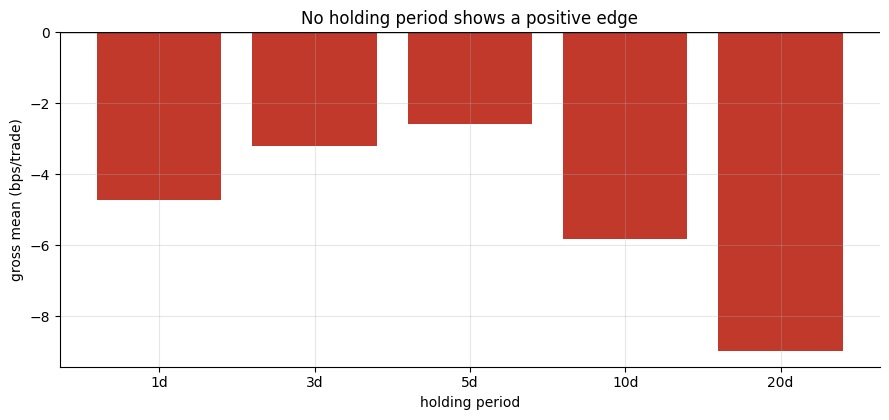

hold= 1d  mean=-4.72bps  t=-2.29
hold= 3d  mean=-3.21bps  t=-1.29
hold= 5d  mean=-2.59bps  t=-0.93
hold=10d  mean=-5.82bps  t=-1.96
hold=20d  mean=-8.98bps  t=-2.43


In [4]:
holds = [1, 3, 5, 10, 20]
if HAVE_REAL:
    means = [st.summarize(pooled(h, 0), 'ret_gross')['mean_bps'] for h in holds]
    tsts  = [st.summarize(pooled(h, 0), 'ret_gross')['tstat'] for h in holds]
else:
    means = [-4.72, -3.21, -2.59, -5.82, -8.98]
    tsts  = [-2.29, -1.29, -0.93, -1.96, -2.43]
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.bar(range(len(holds)), means, color=[RED if m < 0 else GREEN for m in means])
ax.set_xticks(range(len(holds)))
ax.set_xticklabels([f'{h}d' for h in holds])
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('holding period'); ax.set_ylabel('gross mean (bps/trade)')
ax.set_title('No holding period shows a positive edge')
plt.tight_layout(); plt.show()
for h, m, t in zip(holds, means, tsts):
    print(f'hold={h:2d}d  mean={m:+.2f}bps  t={t:+.2f}')

Every holding period is negative. The 1-day result is the most striking: **-4.72 bps** at *t* = **-2.29** -- a statistically significant *loser*. This is consistent with daily return reversion: the Fisher crossover fires in the direction of the day's move, and the next day tends to partially reverse it.

## 5 - The verdict

- **Signal -- None.** Gross HAC *t* = -0.93 at the 5-day horizon; the 1-day result (*t* = -2.29) is a significant *negative* -- the signal is on the wrong side of short-term reversion.
- **Tradability -- Mirage.** Gross edge is already negative at every tested holding period; costs simply compound the loss. No break-even cost exists.
- **Transform adds info? -- No (monotone).** Fisher and raw-x crossovers fire on 100% identical bars. The atanh wrapper is decoration, not signal.

## 6 - Could you actually trade it?

The Fisher crossover fires ~550 times per year per ticker. Even ignoring that the gross edge is already negative, costs turn a coin into a certified loser:

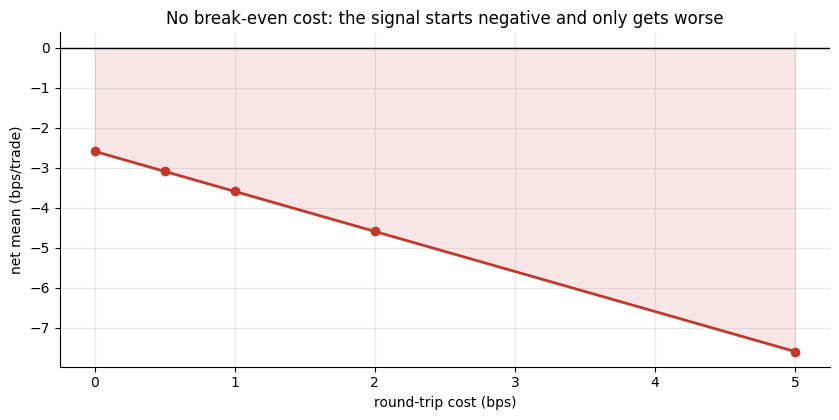

Break-even cost: none (gross is already below zero)


In [5]:
costs = [0.0, 0.5, 1.0, 2.0, 5.0]
if HAVE_REAL:
    net = [st.summarize(pooled(5, c), 'ret_net')['mean_bps'] for c in costs]
else:
    net = [-2.59, -3.09, -3.59, -4.59, -7.59]
fig, ax = plt.subplots(figsize=(8.5, 4.3))
ax.plot(costs, net, 'o-', c=RED, lw=2)
ax.axhline(0, c='k', lw=1)
ax.fill_between(costs, net, 0, where=[n < 0 for n in net], color=RED, alpha=0.12)
ax.set_xlabel('round-trip cost (bps)'); ax.set_ylabel('net mean (bps/trade)')
ax.set_title('No break-even cost: the signal starts negative and only gets worse')
plt.tight_layout(); plt.show()
print('Break-even cost: none (gross is already below zero)')

The line starts below zero and only falls. Because the gross edge is already negative, there is **no cost low enough to make this strategy work** -- the usual 'it dies at the costs line' story doesn't apply here, because the edge was never alive in the first place.

## 7 - Going further

- **What the engine *can* find.** The companion notebook shows a synthetic control: when we plant real momentum in a fake daily tape, this exact crossover finds it. The engine works -- the real market just doesn't have the structure.
- **Why the 1-day result is actually interesting.** The significant negative 1-day result (*t* = -2.29) suggests a short-term *reversal* effect: the Fisher crossover fires in the direction of today's move, and tomorrow reverses it. That's a well-documented microstructure effect -- see [Study 72 — Loaded-Dice](../../72-loaded-dice/) on the same family.
- **Is the Gaussian property real?** Ehlers is right that atanh stretches the tails. But the *crossover* only uses the sign of (today minus yesterday), which is invariant to any monotone transformation. If you use the Fisher *level* (not the crossover) to define overbought/oversold zones, the transform does change the zone boundaries -- but that's a different strategy.

*Think there's a Fisher-based edge? Fork this, test the level-based overbought/oversold version, add a directional filter for the trend regime, and show a fair-bet edge that clears costs. That's the bar.*